
Best objective: 2769 (Rashomon Importance Distribution
--------------------------------
elapsed seconds: 141.01
0.159)
Objective bound: 2852
Minimum objective: 2769
Cache sizes - Greedy: 1207005, Lickety: 53742, Trie: 2047, Trie cache: ON
RID bootstrap 1: Rashomon training = 17.818 s
Finished RID bootstrap: 1 / 5 with 12044 trees
RID bootstrap 1: LOSSLESS feature evaluation = 0.027 s
RID bootstrap 1: post-training RID = 0.027 s
RID bootstrap 1: total = 17.850 s
RID bootstrap 1: training fraction = 99.821%, post-training fraction = 0.152%
Best objective: 2811 (0.162)
Objective bound: 2895
Minimum objective: 2771
Cache sizes - Greedy: 3588944, Lickety: 334914, Trie: 26867, Trie cache: ON
RID bootstrap 2: Rashomon training = 64.687 s
Finished RID bootstrap: 2 / 5 with 10945 trees
RID bootstrap 2: LOSSLESS feature evaluation = 0.031 s
RID bootstrap 2: post-training RID = 0.031 s
RID bootstrap 2: total = 64.724 s
RID bootstrap 2: training fraction = 99.944%, post-training fraction = 0.048%

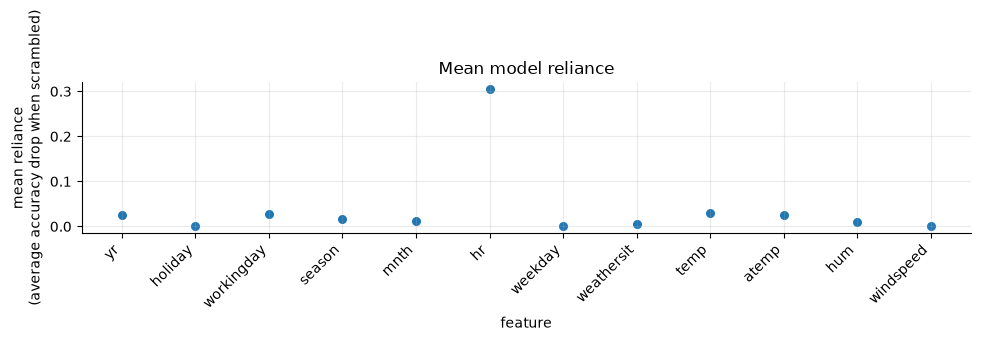

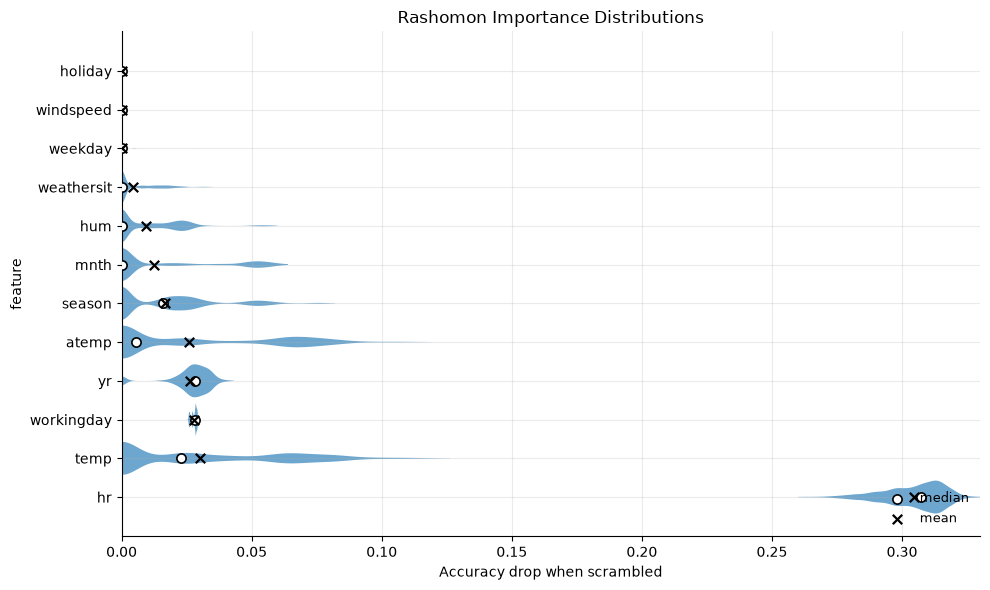

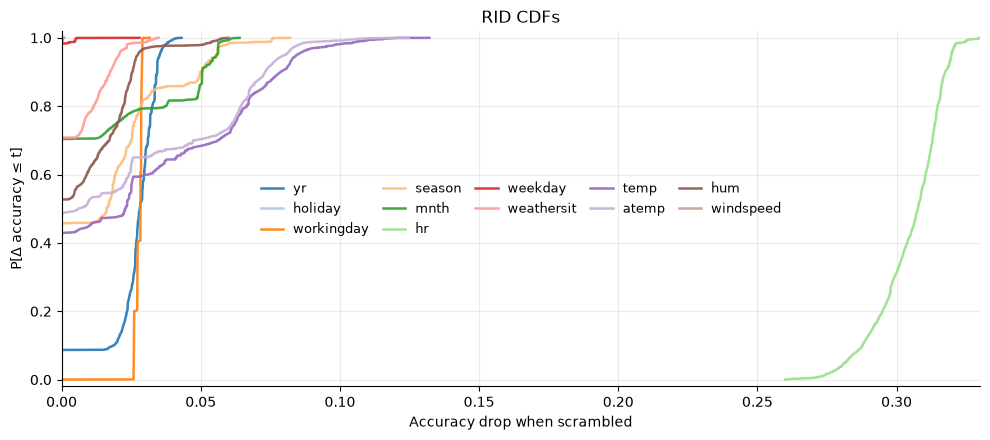


Mean model reliance by feature
------------------------------
   feature  mean_model_reliance
        yr         2.625528e-02
   holiday         1.341072e-07
workingday         2.786390e-02
    season         1.684139e-02
      mnth         1.228713e-02
        hr         3.047529e-01
   weekday         8.223078e-05
weathersit         4.423592e-03
      temp         2.998062e-02
     atemp         2.599840e-02
       hum         9.418656e-03
 windspeed         4.511348e-06


In [ ]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arborenum import ArborEnum

df = pd.read_csv("bike_processed.csv").reset_index(drop=True)

y = df.pop("label").to_numpy(dtype=np.int32)
X = df

model = ArborEnum()

start = time.perf_counter()

rid_result = model.compute_rid(
    X,
    y,
    proxy_mode="hybrid",
    lambda_reg=0.005,
    depth_budget=5,
    rashomon_mult=0.03,
    lookahead_k=1,
    n_boot=5,
)

elapsed = time.perf_counter() - start

print()
print("Rashomon Importance Distribution")
print("--------------------------------")
print("elapsed seconds:", f"{elapsed:.2f}")

model.rid_plot_mean(
    title="Mean model reliance",
    show=True,
)

model.rid_plot_violin(
    title="Rashomon Importance Distributions",
    show=True,
)

model.rid_plot_cdfs(
    title="RID CDFs",
    show=True,
)

plt.show()

print()
print("Mean model reliance by feature")
print("------------------------------")

mean_df = pd.DataFrame({
    "feature": model.rid_feature_names_,
    "mean_model_reliance": rid_result["mean_sub_mr"],
})

print(mean_df.to_string(index=False))